# 08 · Análisis de Pareto: precio y tiempo de desplazamiento

**Análisis de Pareto:** Este método no intenta elegir directamente un único barrio ganador. En su lugar, identifica las alternativas que no pueden mejorarse en precio sin empeorar el tiempo de desplazamiento, o viceversa.

El análisis se realiza por destino, ya que un mismo barrio puede estar bien comunicado con una zona de Madrid y, al mismo tiempo, tener un trayecto bastante peor hacia otra.

Los dos objetivos que se van a minimizar son:

- *price_m2_for_recommender*: precio de referencia de la vivienda por metro cuadrado.
- *commute_daily_minutes*: suma del trayecto de ida por la mañana y del trayecto de vuelta por la tarde.

**NOTA:** Este notebook utiliza únicamente el dataset preparado en el notebook 07. Las rutas incompletas y los casos `no_route` siguen conservados en el dataset completo, pero no entran en el cálculo de Pareto porque no tienen un tiempo diario comparable.

## 1. Importación de librerías



In [719]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 180)

## 2. Localización del proyecto y de los archivos



In [720]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca una carpeta que contenga data/ y notebooks/."""

    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la carpeta principal del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )



In [721]:

PROJECT_ROOT = find_project_root()

FINAL_DIR = PROJECT_ROOT / "data" / "final"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_READY_PATH = FINAL_DIR / "neighborhood_recommender_model_ready.csv"
COMPLETE_DATASET_PATH = FINAL_DIR / "neighborhood_recommender_dataset.csv"

PARETO_RESULTS_PATH = RESULTS_DIR / "pareto_by_destination.csv"
PARETO_FRONT_PATH = RESULTS_DIR / "pareto_front_by_destination.csv"
PARETO_SUMMARY_PATH = RESULTS_DIR / "pareto_summary_by_destination.csv"
PARETO_GLOBAL_PATH = RESULTS_DIR / "pareto_global_accessibility.csv"
PARETO_PROFILES_PATH = RESULTS_DIR / "pareto_profile_examples.csv"


In [722]:
PARETO_TRADEOFF_PATH = (
    RESULTS_DIR
    / "pareto_marginal_tradeoffs.csv"
)

PARETO_SENSITIVITY_PATH = (
    RESULTS_DIR
    / "pareto_weight_sensitivity.csv"
)

In [723]:

print("Raíz del proyecto:", PROJECT_ROOT)
print("Dataset para modelos:", MODEL_READY_PATH)
print("Carpeta de resultados:", RESULTS_DIR)

Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Dataset para modelos: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\final\neighborhood_recommender_model_ready.csv
Carpeta de resultados: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\results


In [724]:
required_paths = [
    MODEL_READY_PATH,
    COMPLETE_DATASET_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_paths
    )

    raise FileNotFoundError(
        "Faltan los siguientes archivos. "
        "Ejecuta primero el notebook 07:\n"
        f"{formatted_paths}"
    )

## 3. Carga de los datos

Se cargan dos archivos:

- El dataset preparado para los modelos, que contiene únicamente rutas completas.
- El dataset completo, que se utiliza solo para comprobar cuántas combinaciones quedaron fuera por tener rutas parciales o inexistentes.

In [725]:
model_data = pd.read_csv(MODEL_READY_PATH)
complete_data = pd.read_csv(COMPLETE_DATASET_PATH)

print("Dataset completo:", complete_data.shape)
print("Dataset preparado para Pareto y KNN:", model_data.shape)

display(model_data.head())

Dataset completo: (393, 139)
Dataset preparado para Pareto y KNN: (371, 139)


,zone_key,neighborhood_name,district_name,has_real_estate_data,price_estimate_available,coverage_status,total_listings,eligible_listings,excluded_listings,eligible_percentage,excluded_percentage,market_share_percentage,num_listings,price_eur_mean,price_eur_median,price_eur_q1,price_eur_q3,price_eur_iqr,price_eur_min,price_eur_max,price_m2_mean,price_m2_median,price_m2_q1,price_m2_q3,price_m2_iqr,price_m2_std,price_m2_relative_iqr_percentage,price_m2_median_ci_low,price_m2_median_ci_high,price_m2_median_ci_width,price_m2_median_ci_relative_width_percentage,price_m2_median_bootstrap_se,bootstrap_sample_size,bootstrap_iterations,bootstrap_confidence_level,bootstrap_status,area_m2_mean,area_m2_median,area_m2_q1,area_m2_q3,area_m2_iqr,area_m2_min,area_m2_max,rooms_mean,rooms_median,rooms_known_count,rooms_unknown_count,rooms_coverage_percentage,bathrooms_mean,bathrooms_median,bathrooms_known_count,bathrooms_unknown_count,bathrooms_coverage_percentage,elevator_ratio,elevator_percentage,elevator_known_count,elevator_unknown_count,elevator_coverage_percentage,exterior_ratio,exterior_percentage,exterior_known_count,exterior_unknown_count,exterior_coverage_percentage,sample_size_score,ci_precision_score,price_homogeneity_score,price_reliability_score,price_reliability_level,price_reliability_reason,market_scope,price_type,source_snapshot_date_status,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,price_m2_for_recommender,price_m2_for_recommender_source,housing_data_availability_status,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,registered_to_kaggle_price_ratio,destination_id,neighborhood_name_transit,district_name_transit,destination_name,service_date,evening_route_status,morning_route_status,morning_start_datetime,morning_end_datetime,morning_transit_modes,morning_routes_used,morning_agencies_used,morning_duration_minutes,morning_walk_time_minutes,morning_waiting_time_minutes,morning_walk_distance_meters,morning_number_of_transfers,evening_start_datetime,evening_end_datetime,evening_transit_modes,evening_routes_used,evening_agencies_used,evening_duration_minutes,evening_walk_time_minutes,evening_waiting_time_minutes,evening_walk_distance_meters,evening_number_of_transfers,commute_daily_minutes,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,no_route_scenarios,route_status,route_available,route_missing_reason,usable_for_pareto_knn
0,MAD-011,Palacio,Centro,True,True,available,308,297,11,96.43,3.57,2.67,297,771118.19,540000.0,349000.0,886000.0,537000.0,150000.0,15000000.0,7003.76,6614.32,5789.47,7480.00,1690.53,2142.05,25.56,6462.96,6898.15,435.19,6.58,113.14,297,2000,0.95,calculated,104.48,90.0,50.0,140.0,90.0,25.0,666.0,2.32,2.0,280,17,94.28,1.68,2.0,59,238,19.87,0.7162,71.62,296,1,99.66,0.7306,73.06,297,0,100.00,94.44,91.27,74.21,88.12,high,La estimación presenta una estabilidad alta en...,residential_sale,asking_price,unknown,6895.15,6421.28,6954.58,130.45,127.37,130.39,100,93.13,100.86,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,504020100060,15,97.7,True,True,88.12,high,6895.15,registered_transactions_2025,official_price_and_kaggle_features,280.83,4.245788,1.042458,DEST_002,Palacio,Centro,Nuevos Ministerios,2026-07-29,success,success,2026-07-29T07:51:00+02:00,2026-

### Primera lectura de los datos

La unidad de análisis no es únicamente el barrio, sino la combinación **barrio–destino**. Por eso un mismo barrio puede aparecer varias veces. Esta estructura es necesaria porque el tiempo de desplazamiento cambia según el destino elegido por el usuario.

In [726]:
key_columns = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
]

objective_columns = [
    "price_m2_for_recommender",
    "commute_daily_minutes",
]

required_columns = key_columns + objective_columns

missing_columns = [
    column
    for column in required_columns
    if column not in model_data.columns
]

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias para el análisis de Pareto: "
        f"{missing_columns}"
    )


In [727]:
print("Barrios presentes:", model_data["zone_key"].nunique())
print("Destinos presentes:", model_data["destination_id"].nunique())
print("Combinaciones barrio–destino:", len(model_data))

display(
    model_data[
        ["destination_id", "destination_name"]
    ]
    .drop_duplicates()
    .sort_values("destination_id")
    .reset_index(drop=True)
)

Barrios presentes: 128
Destinos presentes: 3
Combinaciones barrio–destino: 371


,destination_id,destination_name
0,DEST_001,Puerta del Sol
1,DEST_002,Nuevos Ministerios
2,DEST_003,UC3M Campus de Leganés


## 4. Comprobaciones antes del análisis

Antes de calcular el frente de Pareto se comprueba que:

- No haya combinaciones barrio–destino duplicadas.
- El precio y el tiempo sean valores numéricos y positivos.
- Las filas utilizadas correspondan a rutas completas.
- El tiempo diario coincida, cuando sea posible comprobarlo, con la suma de la ida y la vuelta.

In [728]:
PAIR_KEY = [
    "zone_key",
    "destination_id",
]

duplicate_pairs = (
    model_data[
        model_data.duplicated(
            PAIR_KEY,
            keep=False,
        )
    ]
    .sort_values(PAIR_KEY)
)

In [729]:
print(
    "Combinaciones barrio–destino duplicadas:",
    len(duplicate_pairs),
)

if not duplicate_pairs.empty:
    display(duplicate_pairs)

    raise ValueError(
        "Hay combinaciones barrio–destino duplicadas. "
        "Deben revisarse antes de calcular Pareto."
    )

Combinaciones barrio–destino duplicadas: 0


In [730]:
# Se convierten los objetivos a formato numérico. Si apareciera un valor de texto incorrecto, pasaría a NaN y quedaría reflejado en la comprobación posterior.

for column in objective_columns:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce",
    )

invalid_objectives = model_data[
    model_data[objective_columns].isna().any(axis=1)
    | (model_data[objective_columns] <= 0).any(axis=1)
].copy()


In [731]:

print(
    "Filas con precio o tiempo no válido:",
    len(invalid_objectives),
)

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            key_columns + objective_columns
        ]
    )

Filas con precio o tiempo no válido: 0


In [732]:
# El dataset del notebook 07 debería estar preparado, pero se aplica este filtro de seguridad para que Pareto nunca trabaje con objetivos ausentes o no positivos.

pareto_base = (
    model_data.loc[
        model_data[objective_columns].notna().all(axis=1)
        & (model_data[objective_columns] > 0).all(axis=1)
    ]
    .copy()
    .reset_index(drop=True)
)

if "route_status" in pareto_base.columns:
    invalid_route_status = pareto_base[
        pareto_base["route_status"].ne("complete_route")
    ]

    if not invalid_route_status.empty:
        raise ValueError(
            "El dataset preparado contiene rutas "
            "que no están marcadas como completas."
        )

if "usable_for_pareto_knn" in pareto_base.columns:
    usable_values = (
        pareto_base["usable_for_pareto_knn"]
        .astype(str)
        .str.lower()
    )

    if not usable_values.isin(["true", "1"]).all():
        raise ValueError(
            "Alguna fila del dataset no está marcada "
            "como utilizable para Pareto y KNN."
        )

print(
    "Filas que entrarán en Pareto:",
    len(pareto_base),
)

Filas que entrarán en Pareto: 371


In [733]:
# Comprobación opcional de la suma del trayecto diario.

duration_columns = [
    "morning_duration_minutes",
    "evening_duration_minutes",
]

if all(
    column in pareto_base.columns
    for column in duration_columns
):
    expected_daily_time = (
        pareto_base["morning_duration_minutes"]
        + pareto_base["evening_duration_minutes"]
    )

    inconsistent_daily_time = ~np.isclose(
        pareto_base["commute_daily_minutes"],
        expected_daily_time,
        atol=0.02,
        equal_nan=False,
    )

    print(
        "Filas donde el tiempo diario no coincide "
        "con ida + vuelta:",
        int(inconsistent_daily_time.sum()),
    )

    if inconsistent_daily_time.any():
        display(
            pareto_base.loc[
                inconsistent_daily_time,
                key_columns
                + duration_columns
                + ["commute_daily_minutes"],
            ]
        )

        raise ValueError(
            "Se han encontrado tiempos diarios inconsistentes."
        )
else:
    print(
        "No se han encontrado las columnas separadas "
        "de mañana y tarde. Se utilizará directamente "
        "commute_daily_minutes."
    )

Filas donde el tiempo diario no coincide con ida + vuelta: 0


### Situación de las rutas no utilizables

No se eliminan ni se corrigen los casos sin ruta en el dataset original. Simplemente no se incluyen en este análisis porque no tienen un valor real de tiempo con el que compararlos.

Rellenarlos con una media haría que esos barrios pareciesen tener una accesibilidad que realmente no ha sido calculada.

In [734]:
route_status_summary = (
    complete_data["route_status"]
    .value_counts(dropna=False)
    .rename_axis("route_status")
    .reset_index(name="rows")
)

display(route_status_summary)

usable_mask = (
    complete_data["usable_for_pareto_knn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1"])
)

complete_route_mask = (
    complete_data["route_status"]
    .eq("complete_route")
)

required_recommender_columns = [
    "price_m2_for_recommender",
    "commute_daily_minutes",
    "commute_daily_walk_minutes",
    "commute_daily_waiting_minutes",
    "commute_daily_transfers",
]

missing_required_columns = [
    column
    for column in required_recommender_columns
    if column not in complete_data.columns
]

if missing_required_columns:
    raise KeyError(
        "Faltan columnas necesarias para auditar las exclusiones: "
        f"{missing_required_columns}"
    )

complete_but_not_usable = (
    complete_data.loc[
        complete_route_mask & ~usable_mask,
        key_columns
        + [
            "route_status",
            "usable_for_pareto_knn",
        ]
        + required_recommender_columns,
    ]
    .copy()
    .reset_index(drop=True)
)

complete_but_not_usable["missing_required_fields"] = (
    complete_but_not_usable[
        required_recommender_columns
    ]
    .isna()
    .apply(
        lambda row: ", ".join(
            row.index[row].tolist()
        ),
        axis=1,
    )
)

complete_routes = int(
    complete_route_mask.sum()
)

usable_rows = int(
    usable_mask.sum()
)

incomplete_routes = int(
    (~complete_route_mask).sum()
)

complete_not_usable = len(
    complete_but_not_usable
)

audit_summary = pd.Series(
    {
        "total_combinations": len(complete_data),
        "complete_routes": complete_routes,
        "partial_or_no_route": incomplete_routes,
        "usable_for_pareto_knn": usable_rows,
        "complete_but_not_usable": complete_not_usable,
    },
    name="rows",
)

display(
    audit_summary.to_frame()
)

if not complete_but_not_usable.empty:
    display(
        complete_but_not_usable
    )

display(
    Markdown(
        f"""
En el dataset completo hay **{len(complete_data)} combinaciones
barrio–destino**. De ellas, **{complete_routes}** disponen de
ida y vuelta completas y **{usable_rows}** cumplen además todos
los requisitos necesarios para utilizarse en Pareto y KNN.

Las **{incomplete_routes}** combinaciones con ruta parcial o sin
ruta se conservan sin imputar tiempos. Además,
**{complete_not_usable}** combinaciones tienen una ruta completa,
pero no se incorporan al dataset de modelos porque les falta al
menos una variable requerida. La tabla anterior permite identificar
exactamente cuáles son esas variables.
"""
    )
)

,route_status,rows
0,complete_route,373
1,no_route,17
2,partial_route,3


,rows
total_combinations,393
complete_routes,373
partial_or_no_route,20
usable_for_pareto_knn,371
complete_but_not_usable,2


,zone_key,neighborhood_name,district_name,destination_id,destination_name,route_status,usable_for_pareto_knn,price_m2_for_recommender,commute_daily_minutes,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,missing_required_fields
0,MAD-212,Aeropuerto,Barajas,DEST_001,Puerta del Sol,complete_route,False,NaN,232.866667,107.433333,35.8,4.0,price_m2_for_recommender
1,MAD-212,Aeropuerto,Barajas,DEST_002,Nuevos Ministerios,complete_route,False,NaN,180.483333,117.000000,16.7,3.0,price_m2_for_recommender



En el dataset completo hay **393 combinaciones
barrio–destino**. De ellas, **373** disponen de
ida y vuelta completas y **371** cumplen además todos
los requisitos necesarios para utilizarse en Pareto y KNN.

Las **20** combinaciones con ruta parcial o sin
ruta se conservan sin imputar tiempos. Además,
**2** combinaciones tienen una ruta completa,
pero no se incorporan al dataset de modelos porque les falta al
menos una variable requerida. La tabla anterior permite identificar
exactamente cuáles son esas variables.


## 5. ¿Qué significa que una zona sea Pareto-óptima?

Una alternativa domina a otra cuando cumple las dos condiciones siguientes:

1. Tiene un precio igual o menor.
2. Tiene un tiempo de desplazamiento igual o menor.

Además, debe ser estrictamente mejor en al menos uno de los dos objetivos.

**EJEMPLO:** Si un barrio es más barato y también permite llegar antes al mismo destino, resulta claramente preferible al otro dentro de estos dos criterios. Las alternativas que no son dominadas por ninguna otra forman el **frente de Pareto**.

In [735]:
def pareto_mask_minimization(
    values: np.ndarray,
) -> np.ndarray:
    """
    Devuelve True para las filas no dominadas.

    Todos los objetivos deben minimizarse.
    En este caso:
    - menor precio;
    - menor tiempo.
    """

    values = np.asarray(values, dtype=float)

    number_of_rows = len(values)
    is_pareto = np.ones(
        number_of_rows,
        dtype=bool,
    )

    for current_index in range(number_of_rows):
        current_values = values[current_index]

        # Una fila domina a la actual si es igual o mejor en todos los objetivos y mejor en al menos uno.
        dominates_current = (
            np.all(
                values <= current_values,
                axis=1,
            )
            & np.any(
                values < current_values,
                axis=1,
            )
        )

        dominates_current[current_index] = False

        if dominates_current.any():
            is_pareto[current_index] = False

    return is_pareto




In [736]:
def count_dominators(
    values: np.ndarray,
) -> np.ndarray:
    """
    Cuenta cuántas alternativas dominan a cada fila.

    Un valor 0 significa que la alternativa pertenece
    al frente de Pareto.
    """

    values = np.asarray(values, dtype=float)

    counts = np.zeros(
        len(values),
        dtype=int,
    )

    for current_index in range(len(values)):
        current_values = values[current_index]

        dominates_current = (
            np.all(
                values <= current_values,
                axis=1,
            )
            & np.any(
                values < current_values,
                axis=1,
            )
        )

        dominates_current[current_index] = False
        counts[current_index] = int(
            dominates_current.sum()
        )

    return counts

## 6. Cálculo del frente de Pareto por destino

El frente se calcula de forma independiente para cada destino. Esto evita comparar, por ejemplo, un trayecto hacia Nuevos Ministerios con otro hacia una universidad o hacia un punto completamente distinto.

También se calcula una distancia normalizada al punto ideal. Esta medida no sustituye a Pareto: únicamente ayuda a localizar, dentro del frente, una alternativa bastante equilibrada entre precio y tiempo.

In [737]:
PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

In [738]:
def min_max_normalize(
    series: pd.Series,
) -> pd.Series:
    """Normaliza una variable entre 0 y 1."""

    minimum = series.min()
    maximum = series.max()
    value_range = maximum - minimum

    if np.isclose(value_range, 0):
        return pd.Series(
            0.0,
            index=series.index,
        )

    return (
        series - minimum
    ) / value_range

In [739]:
def calculate_pareto_by_destination(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """Calcula Pareto dentro de cada destino."""

    result_parts = []

    for destination_id, group in data.groupby(
        "destination_id",
        sort=True,
    ):
        group = group.copy()

        values = group[
            [PRICE_COLUMN, TIME_COLUMN]
        ].to_numpy(dtype=float)

        group["is_pareto"] = (
            pareto_mask_minimization(values)
        )

        group["dominated_by_count"] = (
            count_dominators(values)
        )

        group["price_normalized"] = (
            min_max_normalize(
                group[PRICE_COLUMN]
            )
        )

        group["time_normalized"] = (
            min_max_normalize(
                group[TIME_COLUMN]
            )
        )

        # El punto ideal tendría precio normalizado 0 y tiempo normalizado 0.
        group["distance_to_ideal"] = np.sqrt(
            group["price_normalized"] ** 2
            + group["time_normalized"] ** 2
        )

        group["pareto_balance_rank"] = pd.NA

        pareto_indices = (
            group.loc[group["is_pareto"]]
            .sort_values(
                [
                    "distance_to_ideal",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                ]
            )
            .index
        )

        group.loc[
            pareto_indices,
            "pareto_balance_rank",
        ] = range(
            1,
            len(pareto_indices) + 1,
        )

        result_parts.append(group)

    result = pd.concat(
        result_parts,
        ignore_index=True,
    )

    result["pareto_balance_rank"] = (
        result["pareto_balance_rank"]
        .astype("Int64")
    )

    return result


pareto_results = calculate_pareto_by_destination(
    pareto_base
)

pareto_front = (
    pareto_results.loc[
        pareto_results["is_pareto"]
    ]
    .copy()
    .sort_values(
        [
            "destination_id",
            PRICE_COLUMN,
            TIME_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


In [740]:
print(
    "Alternativas analizadas:",
    len(pareto_results),
)

print(
    "Alternativas situadas en algún frente de Pareto:",
    len(pareto_front),
)

Alternativas analizadas: 371
Alternativas situadas en algún frente de Pareto: 28


## 7. Resumen de resultados por destino

En la tabla siguientE:

- Cuántas alternativas se han comparado para cada destino.
- Cuántas pertenecen al frente de Pareto.
- Qué barrio es el más barato.
- Qué barrio tiene el trayecto más rápido.
- Qué barrio aparece como la opción más equilibrada dentro del frente.

**NOTA:** La opción equilibrada se obtiene mediante la distancia al punto ideal después de normalizar precio y tiempo. No debe entenderse como una decisión universal, sino como una referencia neutral cuando todavía no se han indicado preferencias concretas. La pertenencia al frente de Pareto no depende de esta normalización. La normalización solo se utiliza para seleccionar una referencia equilibrada dentro del frente, por lo que dicha selección puede variar si se emplea otro método de escalado.

In [741]:
def build_destination_summary(
    results: pd.DataFrame,
) -> pd.DataFrame:
    """Genera un resumen legible para cada destino."""

    summary_rows = []

    for destination_id, group in results.groupby(
        "destination_id",
        sort=True,
    ):
        destination_name = (
            group["destination_name"]
            .dropna()
            .iloc[0]
        )

        front = group[
            group["is_pareto"]
        ].copy()

        cheapest = group.sort_values(
            [PRICE_COLUMN, TIME_COLUMN]
        ).iloc[0]

        fastest = group.sort_values(
            [TIME_COLUMN, PRICE_COLUMN]
        ).iloc[0]

        balanced = front.sort_values(
            [
                "distance_to_ideal",
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        ).iloc[0]

        summary_rows.append(
            {
                "destination_id": destination_id,
                "destination_name": destination_name,
                "alternatives": len(group),
                "pareto_alternatives": len(front),
                "pareto_percentage": round(
                    len(front) / len(group) * 100,
                    2,
                ),
                "cheapest_neighborhood": cheapest[
                    "neighborhood_name"
                ],
                "cheapest_price_eur_m2": round(
                    cheapest[PRICE_COLUMN],
                    2,
                ),
                "cheapest_commute_minutes": round(
                    cheapest[TIME_COLUMN],
                    2,
                ),
                "fastest_neighborhood": fastest[
                    "neighborhood_name"
                ],
                "fastest_commute_minutes": round(
                    fastest[TIME_COLUMN],
                    2,
                ),
                "fastest_price_eur_m2": round(
                    fastest[PRICE_COLUMN],
                    2,
                ),
                "balanced_neighborhood": balanced[
                    "neighborhood_name"
                ],
                "balanced_price_eur_m2": round(
                    balanced[PRICE_COLUMN],
                    2,
                ),
                "balanced_commute_minutes": round(
                    balanced[TIME_COLUMN],
                    2,
                ),
            }
        )

    return pd.DataFrame(summary_rows)



In [742]:
pareto_summary = build_destination_summary(
    pareto_results
)

display(pareto_summary)

,destination_id,destination_name,alternatives,pareto_alternatives,pareto_percentage,cheapest_neighborhood,cheapest_price_eur_m2,cheapest_commute_minutes,fastest_neighborhood,fastest_commute_minutes,fastest_price_eur_m2,balanced_neighborhood,balanced_price_eur_m2,balanced_commute_minutes
0,DEST_001,Puerta del Sol,119,13,10.92,San Cristóbal,1909.6,139.72,Recoletos,56.37,14108.83,Puerta del Ángel,4033.30,65.13
1,DEST_002,Nuevos Ministerios,124,10,8.06,San Cristóbal,1909.6,174.28,Almagro,44.97,10795.41,Rejas,3580.16,82.27
2,DEST_003,UC3M Campus de Leganés,128,5,3.91,San Cristóbal,1909.6,136.33,Buenavista,51.62,3291.57,Buenavista,3291.57,51.62


In [743]:
for _, row in pareto_summary.iterrows():
    destination = row["destination_name"]

    display(
        Markdown(
            f"""
### {destination}

Para este destino se han comparado **{int(row['alternatives'])} barrios** con datos completos de transporte. De todos ellos, **{int(row['pareto_alternatives'])} forman parte del frente de Pareto**, lo que supone aproximadamente un **{row['pareto_percentage']:.2f} %** del total.

- El barrio más barato es **{row['cheapest_neighborhood']}**, con un precio de **{row['cheapest_price_eur_m2']:,.2f} €/m²**. A cambio, el desplazamiento diario es de unos **{row['cheapest_commute_minutes']:.2f} minutos**.
- El barrio con el trayecto más rápido es **{row['fastest_neighborhood']}**, con **{row['fastest_commute_minutes']:.2f} minutos diarios**, aunque su precio sube hasta los **{row['fastest_price_eur_m2']:,.2f} €/m²**.
- Como opción más equilibrada aparece **{row['balanced_neighborhood']}**, con un precio de **{row['balanced_price_eur_m2']:,.2f} €/m²** y un desplazamiento diario de **{row['balanced_commute_minutes']:.2f} minutos**.

En este caso se puede ver que no hay un barrio que sea claramente el mejor en todo. Algunos tienen un precio más bajo, mientras que otros permiten ahorrar tiempo en los desplazamientos. Por eso, la elección final dependerá de qué valore más cada persona.
"""
        )
    )


### Puerta del Sol

Para este destino se han comparado **119 barrios** con datos completos de transporte. De todos ellos, **13 forman parte del frente de Pareto**, lo que supone aproximadamente un **10.92 %** del total.

- El barrio más barato es **San Cristóbal**, con un precio de **1,909.60 €/m²**. A cambio, el desplazamiento diario es de unos **139.72 minutos**.
- El barrio con el trayecto más rápido es **Recoletos**, con **56.37 minutos diarios**, aunque su precio sube hasta los **14,108.83 €/m²**.
- Como opción más equilibrada aparece **Puerta del Ángel**, con un precio de **4,033.30 €/m²** y un desplazamiento diario de **65.13 minutos**.

En este caso se puede ver que no hay un barrio que sea claramente el mejor en todo. Algunos tienen un precio más bajo, mientras que otros permiten ahorrar tiempo en los desplazamientos. Por eso, la elección final dependerá de qué valore más cada persona.



### Nuevos Ministerios

Para este destino se han comparado **124 barrios** con datos completos de transporte. De todos ellos, **10 forman parte del frente de Pareto**, lo que supone aproximadamente un **8.06 %** del total.

- El barrio más barato es **San Cristóbal**, con un precio de **1,909.60 €/m²**. A cambio, el desplazamiento diario es de unos **174.28 minutos**.
- El barrio con el trayecto más rápido es **Almagro**, con **44.97 minutos diarios**, aunque su precio sube hasta los **10,795.41 €/m²**.
- Como opción más equilibrada aparece **Rejas**, con un precio de **3,580.16 €/m²** y un desplazamiento diario de **82.27 minutos**.

En este caso se puede ver que no hay un barrio que sea claramente el mejor en todo. Algunos tienen un precio más bajo, mientras que otros permiten ahorrar tiempo en los desplazamientos. Por eso, la elección final dependerá de qué valore más cada persona.



### UC3M Campus de Leganés

Para este destino se han comparado **128 barrios** con datos completos de transporte. De todos ellos, **5 forman parte del frente de Pareto**, lo que supone aproximadamente un **3.91 %** del total.

- El barrio más barato es **San Cristóbal**, con un precio de **1,909.60 €/m²**. A cambio, el desplazamiento diario es de unos **136.33 minutos**.
- El barrio con el trayecto más rápido es **Buenavista**, con **51.62 minutos diarios**, aunque su precio sube hasta los **3,291.57 €/m²**.
- Como opción más equilibrada aparece **Buenavista**, con un precio de **3,291.57 €/m²** y un desplazamiento diario de **51.62 minutos**.

En este caso se puede ver que no hay un barrio que sea claramente el mejor en todo. Algunos tienen un precio más bajo, mientras que otros permiten ahorrar tiempo en los desplazamientos. Por eso, la elección final dependerá de qué valore más cada persona.


## 8. Tabla detallada de las alternativas Pareto-óptimas

Para facilitar la interpretación se añade un precio orientativo para una vivienda de 80 m². Esta cifra es solo una conversión del precio por metro cuadrado y no una tasación individual de una vivienda concreta.

In [744]:
pareto_front["reference_price_80m2_eur"] = (
    pareto_front[PRICE_COLUMN]
    * 80
)

In [745]:
front_display_columns = [
    "destination_name",
    "neighborhood_name",
    "district_name",
    PRICE_COLUMN,
    "reference_price_80m2_eur",
    TIME_COLUMN,
]

In [746]:
optional_front_columns = [
    "morning_duration_minutes",
    "evening_duration_minutes",
    "commute_daily_walk_minutes",
    "commute_daily_waiting_minutes",
    "commute_daily_transfers",
    "price_m2_for_recommender_source",
    "housing_data_availability_status",
    "kaggle_sample_reliability_level",
    "pareto_balance_rank",
]

In [747]:
front_display_columns += [
    column
    for column in optional_front_columns
    if column in pareto_front.columns
]

In [748]:
pareto_front_table = (
    pareto_front[
        front_display_columns
    ]
    .copy()
)

In [749]:
numeric_columns_to_round = [
    PRICE_COLUMN,
    "reference_price_80m2_eur",
    TIME_COLUMN,
    "morning_duration_minutes",
    "evening_duration_minutes",
    "commute_daily_walk_minutes",
    "commute_daily_waiting_minutes",
    "commute_daily_transfers",
]

In [750]:
for column in numeric_columns_to_round:
    if column in pareto_front_table.columns:
        pareto_front_table[column] = (
            pareto_front_table[column]
            .round(2)
        )

display(pareto_front_table)

,destination_name,neighborhood_name,district_name,price_m2_for_recommender,reference_price_80m2_eur,commute_daily_minutes,morning_duration_minutes,evening_duration_minutes,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,price_m2_for_recommender_source,housing_data_availability_status,kaggle_sample_reliability_level,pareto_balance_rank
0,Puerta del Sol,San Cristóbal,Villaverde,1909.60,152768.0,139.72,70.28,69.43,62.32,22.07,2.0,registered_transactions_2025,official_price_and_kaggle_features,low,12
1,Puerta del Sol,Orcasitas,Usera,2357.51,188600.8,135.12,64.83,70.28,33.45,19.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,11
2,Puerta del Sol,Entrevías,Puente de Vallecas,2430.16,194412.8,122.70,61.20,61.50,41.68,26.00,1.0,registered_transactions_2025,official_price_and_kaggle_features,low,10
3,Puerta del Sol,San Fermín,Usera,2755.18,220414.4,111.68,53.37,58.32,20.62,16.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,7
4,Puerta del Sol,San Diego,Puente de Vallecas,3078.32,246265.6,109.92,54.97,54.95,27.98,27.00,1.0,registered_transactions_2025,official_price_and_kaggle_features,medium,6
5,Puerta del Sol,Vista Alegre,Carabanchel,3213.22,257057.6,102.50,51.35,51.15,18.42,20.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,medium,5
6,Puerta del Sol,Lucero,Latina,3310.43,264834.4,96.10,49.67,46.43,30.88,22.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,4
7,Puerta del Sol,Opañel,Carabanchel,3500.89,280071.2,83.75,42.55,41.20,34.95,16.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,medium,3
8,Puerta del Sol,Moscardó,Usera,3739.18,299134.4,79.50,39.10,40.40,22.85,16.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,2
9,Puerta del Sol,Puerta del Ángel,Latina,4033.30,322664.0,65.13,32.07,33.07,25.88,15.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,medium,1


### Coste marginal de reducir el tiempo de desplazamiento

Además de identificar las alternativas Pareto-óptimas, resulta útil cuantificar el intercambio entre precio y tiempo a lo largo del frente.

Para cada destino, las alternativas se ordenan de menor a mayor precio. Después se calcula cuánto aumenta el precio por metro cuadrado y cuántos minutos diarios se ahorran al pasar desde una alternativa a la siguiente.

También se presenta el incremento orientativo de precio para una vivienda de 80 m². Esta comparación no representa el precio de una vivienda concreta ni incorpora impuestos, gastos de compraventa o reformas.

In [751]:
tradeoff_parts = []

for destination_id, front in pareto_front.groupby(
    "destination_id",
    sort=True,
):
    ordered_front = (
        front.sort_values(
            [
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        )
        .copy()
        .reset_index(drop=True)
    )

    ordered_front[
        "extra_price_eur_m2_vs_previous"
    ] = ordered_front[
        PRICE_COLUMN
    ].diff()

    ordered_front[
        "daily_minutes_saved_vs_previous"
    ] = -ordered_front[
        TIME_COLUMN
    ].diff()

    ordered_front[
        "extra_reference_price_80m2_vs_previous_eur"
    ] = (
        ordered_front[
            "extra_price_eur_m2_vs_previous"
        ]
        * 80
    )

    ordered_front[
        "extra_reference_price_80m2_per_daily_minute_saved"
    ] = (
        ordered_front[
            "extra_reference_price_80m2_vs_previous_eur"
        ]
        / ordered_front[
            "daily_minutes_saved_vs_previous"
        ]
    )

    tradeoff_parts.append(
        ordered_front
    )

marginal_tradeoffs = pd.concat(
    tradeoff_parts,
    ignore_index=True,
)

tradeoff_display_columns = [
    "destination_name",
    "neighborhood_name",
    "district_name",
    PRICE_COLUMN,
    TIME_COLUMN,
    "extra_price_eur_m2_vs_previous",
    "daily_minutes_saved_vs_previous",
    "extra_reference_price_80m2_vs_previous_eur",
    "extra_reference_price_80m2_per_daily_minute_saved",
]

display(
    marginal_tradeoffs[
        tradeoff_display_columns
    ].round(2)
)

,destination_name,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,extra_price_eur_m2_vs_previous,daily_minutes_saved_vs_previous,extra_reference_price_80m2_vs_previous_eur,extra_reference_price_80m2_per_daily_minute_saved
0,Puerta del Sol,San Cristóbal,Villaverde,1909.60,139.72,NaN,NaN,NaN,NaN
1,Puerta del Sol,Orcasitas,Usera,2357.51,135.12,447.91,4.60,35832.8,7789.74
2,Puerta del Sol,Entrevías,Puente de Vallecas,2430.16,122.70,72.65,12.42,5812.0,468.08
3,Puerta del Sol,San Fermín,Usera,2755.18,111.68,325.02,11.02,26001.6,2360.21
4,Puerta del Sol,San Diego,Puente de Vallecas,3078.32,109.92,323.14,1.77,25851.2,14632.75
5,Puerta del Sol,Vista Alegre,Carabanchel,3213.22,102.50,134.90,7.42,10792.0,1455.10
6,Puerta del Sol,Lucero,Latina,3310.43,96.10,97.21,6.40,7776.8,1215.12
7,Puerta del Sol,Opañel,Carabanchel,3500.89,83.75,190.46,12.35,15236.8,1233.75
8,Puerta del Sol,Moscardó,Usera,3739.18,79.50,238.29,4.25,19063.2,4485.46
9,Puerta del Sol,Puerta del Ángel,Latina,4033.30,65.13,294.12,14.37,23529.6,1637.79


## 9. Representación gráfica por destino

En cada gráfico:

- El eje horizontal representa el precio por metro cuadrado.
- El eje vertical representa los minutos diarios de desplazamiento.
- Las alternativas del frente se unen siguiendo el orden del precio.
- Los barrios situados más cerca de la esquina inferior izquierda son, en principio, más atractivos porque combinan un precio y un tiempo menores.

**NOTA:** Aun así, no siempre existe un barrio en esa esquina. Precisamente por eso aparece una curva de compromiso entre ambos objetivos.

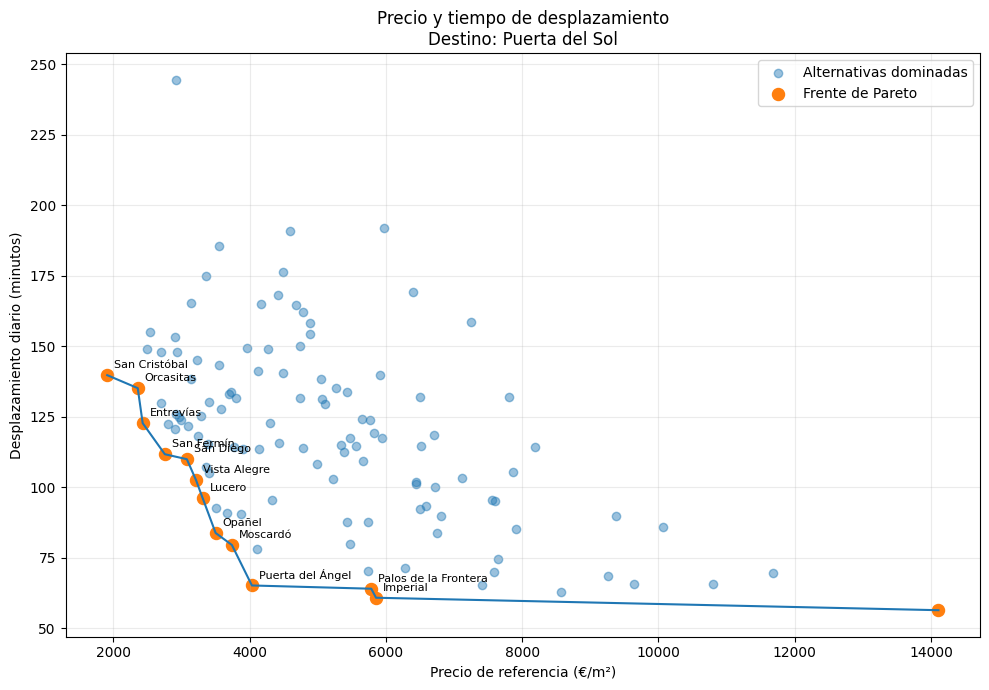

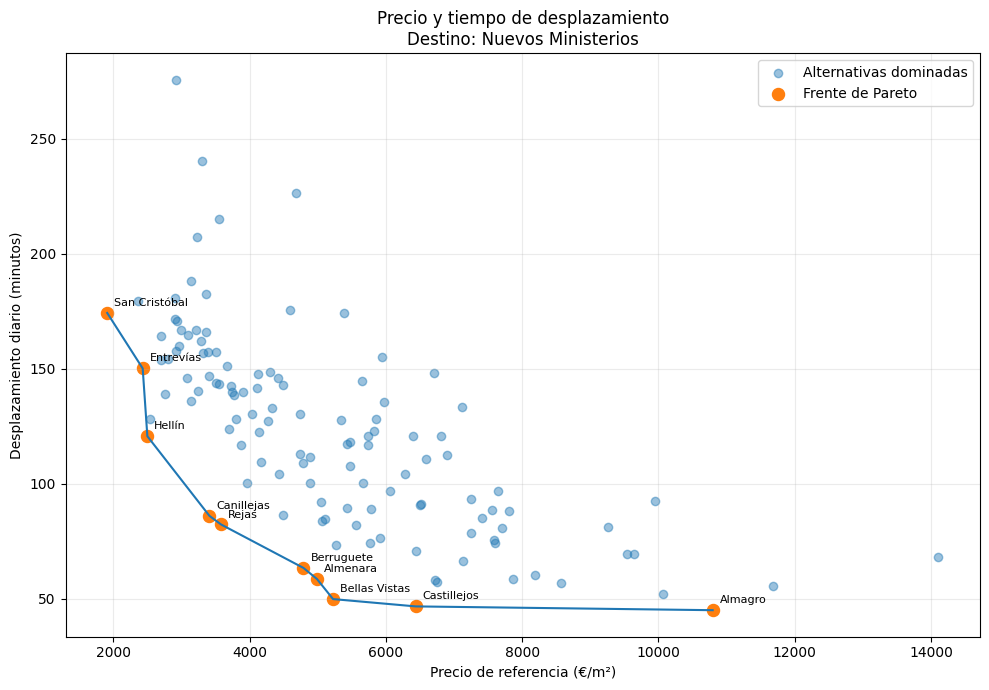

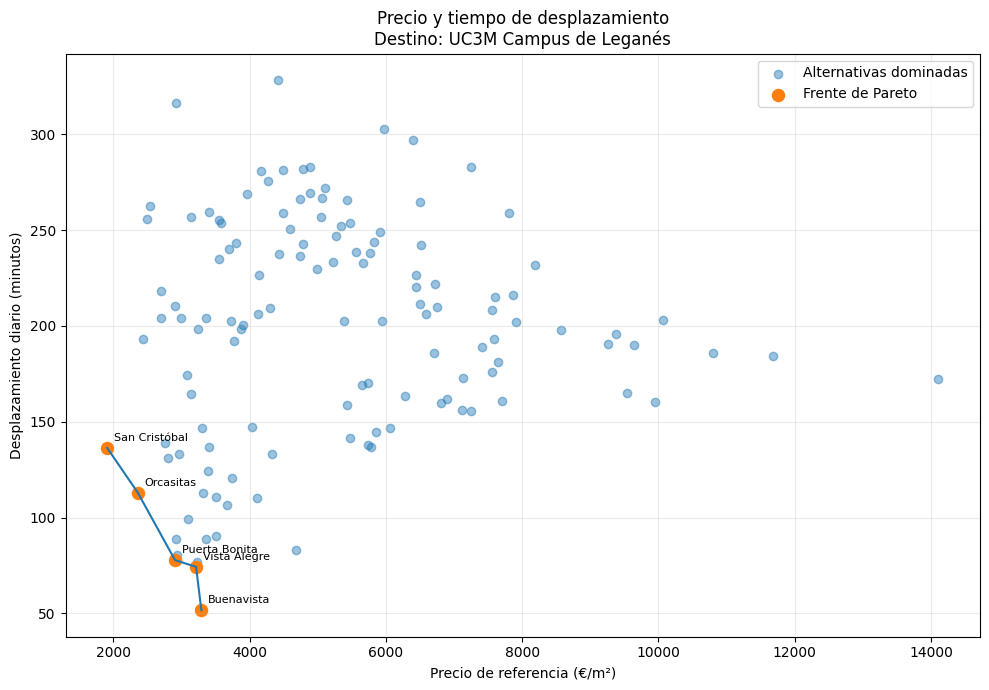

In [752]:
def plot_pareto_destination(
    group: pd.DataFrame,
) -> None:
    """Representa las alternativas y el frente de un destino."""

    destination_name = (
        group["destination_name"]
        .dropna()
        .iloc[0]
    )

    dominated = group[
        ~group["is_pareto"]
    ]

    front = (
        group[group["is_pareto"]]
        .sort_values(PRICE_COLUMN)
    )

    plt.figure(figsize=(10, 7))

    plt.scatter(
        dominated[PRICE_COLUMN],
        dominated[TIME_COLUMN],
        alpha=0.45,
        label="Alternativas dominadas",
    )

    plt.scatter(
        front[PRICE_COLUMN],
        front[TIME_COLUMN],
        s=75,
        label="Frente de Pareto",
    )

    plt.plot(
        front[PRICE_COLUMN],
        front[TIME_COLUMN],
        linewidth=1.5,
    )

    # Si el frente es muy grande, se etiquetan primero las alternativas más equilibradas para evitar que el gráfico quede completamente cubierto.
    labels_to_show = (
        front.sort_values(
            "distance_to_ideal"
        )
        .head(12)
    )

    for _, row in labels_to_show.iterrows():
        plt.annotate(
            row["neighborhood_name"],
            (
                row[PRICE_COLUMN],
                row[TIME_COLUMN],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    plt.xlabel("Precio de referencia (€/m²)")
    plt.ylabel("Desplazamiento diario (minutos)")
    plt.title(
        "Precio y tiempo de desplazamiento\n"
        f"Destino: {destination_name}"
    )
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


for _, destination_group in pareto_results.groupby(
    "destination_id",
    sort=True,
):
    plot_pareto_destination(
        destination_group
    )

### Cómo interpretar los gráficos

Los puntos que quedan por encima y a la derecha de otros puntos están normalmente dominados: existe al menos otro barrio que es igual o mejor en ambos criterios.

En cambio, los puntos del frente representan compromisos razonables. Al moverse por la curva:

- hacia la izquierda se reduce el precio, pero normalmente aumenta el tiempo;
- hacia abajo se reduce el tiempo, pero normalmente aumenta el precio.


## 10. Ejemplo de selección según distintas prioridades

El frente de Pareto indica qué alternativas son eficientes, pero no las ordena de forma definitiva.

Para mostrar cómo podrían cambiar las recomendaciones se prueban tres perfiles sencillos:

- **Prioridad al precio:** 75 % precio y 25 % tiempo.
- **Perfil equilibrado:** 50 % precio y 50 % tiempo.
- **Prioridad al tiempo:** 25 % precio y 75 % tiempo.

**NOTA:** Los pesos se utilizan únicamente como ejemplo. En la versión final del recomendador deberían proceder de las preferencias introducidas por el usuario.

Las puntuaciones se calculan utilizando el precio y el tiempo normalizados dentro de cada destino. Ambas variables quedan expresadas en una escala comparable entre 0 y 1 antes de aplicar los pesos.

**ACLARACIÓN:** Estos ejemplos no constituyen todavía perfiles completos de usuario. Representan únicamente distintas prioridades entre precio y tiempo. Restricciones como el presupuesto máximo, el tiempo máximo aceptable, el número de habitaciones, el ascensor o la tolerancia a los transbordos se incorporarán en la fase posterior de personalización del recomendador.

In [753]:
PROFILE_WEIGHTS = {
    "price_priority": {
        "label": "Prioridad al precio",
        "price_weight": 0.75,
        "time_weight": 0.25,
    },
    "balanced": {
        "label": "Perfil equilibrado",
        "price_weight": 0.50,
        "time_weight": 0.50,
    },
    "time_priority": {
        "label": "Prioridad al tiempo",
        "price_weight": 0.25,
        "time_weight": 0.75,
    },
}

In [754]:
def build_profile_examples(
    results: pd.DataFrame,
) -> pd.DataFrame:
    """Selecciona una alternativa del frente para cada perfil."""

    profile_rows = []

    for destination_id, group in results.groupby(
        "destination_id",
        sort=True,
    ):
        front = (
            group[group["is_pareto"]]
            .copy()
        )

        destination_name = (
            front["destination_name"]
            .dropna()
            .iloc[0]
        )

        for profile_id, profile in PROFILE_WEIGHTS.items():
            front["profile_score"] = (
                profile["price_weight"]
                * front["price_normalized"]
                + profile["time_weight"]
                * front["time_normalized"]
            )

            selected = front.sort_values(
                [
                    "profile_score",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                ]
            ).iloc[0]

            profile_rows.append(
                {
                    "destination_id": destination_id,
                    "destination_name": destination_name,
                    "profile_id": profile_id,
                    "profile_name": profile["label"],
                    "price_weight": profile["price_weight"],
                    "time_weight": profile["time_weight"],
                    "zone_key": selected["zone_key"],
                    "neighborhood_name": selected[
                        "neighborhood_name"
                    ],
                    "district_name": selected[
                        "district_name"
                    ],
                    "price_eur_m2": round(
                        selected[PRICE_COLUMN],
                        2,
                    ),
                    "commute_daily_minutes": round(
                        selected[TIME_COLUMN],
                        2,
                    ),
                    "profile_score": round(
                        selected["profile_score"],
                        4,
                    ),
                }
            )

    return pd.DataFrame(profile_rows)


In [755]:
profile_examples = build_profile_examples(
    pareto_results
)

display(profile_examples)

,destination_id,destination_name,profile_id,profile_name,price_weight,time_weight,zone_key,neighborhood_name,district_name,price_eur_m2,commute_daily_minutes,profile_score
0,DEST_001,Puerta del Sol,price_priority,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,Villaverde,1909.60,139.72,0.1107
1,DEST_001,Puerta del Sol,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,65.13,0.1103
2,DEST_001,Puerta del Sol,time_priority,Prioridad al tiempo,0.25,0.75,MAD-102,Puerta del Ángel,Latina,4033.30,65.13,0.0785
3,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.75,0.25,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.65,0.1182
4,DEST_002,Nuevos Ministerios,balanced,Perfil equilibrado,0.50,0.50,MAD-061,Bellas Vistas,Tetuán,5223.92,49.80,0.1463
5,DEST_002,Nuevos Ministerios,time_priority,Prioridad al tiempo,0.25,0.75,MAD-061,Bellas Vistas,Tetuán,5223.92,49.80,0.0836
6,DEST_003,UC3M Campus de Leganés,price_priority,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,Villaverde,1909.60,136.33,0.0765
7,DEST_003,UC3M Campus de Leganés,balanced,Perfil equilibrado,0.50,0.50,MAD-116,Buenavista,Carabanchel,3291.57,51.62,0.0566
8,DEST_003,UC3M Campus de Leganés,time_priority,Prioridad al tiempo,0.25,0.75,MAD-116,Buenavista,Carabanchel,3291.57,51.62,0.0283


In [756]:
for destination_name, group in profile_examples.groupby(
    "destination_name",
    sort=True,
):
    lines = []

    for _, row in group.iterrows():
        lines.append(
            f"- **{row['profile_name']}**: "
            f"{row['neighborhood_name']} "
            f"({row['price_eur_m2']:,.2f} €/m² y "
            f"{row['commute_daily_minutes']:.2f} minutos diarios)."
        )

    display(
        Markdown(
            f"""
### Ejemplo para {destination_name}

{chr(10).join(lines)}

Las diferencias entre perfiles permiten comprobar que la recomendación no depende solo de los datos disponibles, sino también de las preferencias de la persona que utilizará el sistema.
"""
        )
    )


### Ejemplo para Nuevos Ministerios

- **Prioridad al precio**: Hellín (2,498.86 €/m² y 120.65 minutos diarios).
- **Perfil equilibrado**: Bellas Vistas (5,223.92 €/m² y 49.80 minutos diarios).
- **Prioridad al tiempo**: Bellas Vistas (5,223.92 €/m² y 49.80 minutos diarios).

Las diferencias entre perfiles permiten comprobar que la recomendación no depende solo de los datos disponibles, sino también de las preferencias de la persona que utilizará el sistema.



### Ejemplo para Puerta del Sol

- **Prioridad al precio**: San Cristóbal (1,909.60 €/m² y 139.72 minutos diarios).
- **Perfil equilibrado**: Puerta del Ángel (4,033.30 €/m² y 65.13 minutos diarios).
- **Prioridad al tiempo**: Puerta del Ángel (4,033.30 €/m² y 65.13 minutos diarios).

Las diferencias entre perfiles permiten comprobar que la recomendación no depende solo de los datos disponibles, sino también de las preferencias de la persona que utilizará el sistema.



### Ejemplo para UC3M Campus de Leganés

- **Prioridad al precio**: San Cristóbal (1,909.60 €/m² y 136.33 minutos diarios).
- **Perfil equilibrado**: Buenavista (3,291.57 €/m² y 51.62 minutos diarios).
- **Prioridad al tiempo**: Buenavista (3,291.57 €/m² y 51.62 minutos diarios).

Las diferencias entre perfiles permiten comprobar que la recomendación no depende solo de los datos disponibles, sino también de las preferencias de la persona que utilizará el sistema.


### 10.1. Análisis de sensibilidad de las preferencias

Los tres perfiles anteriores permiten mostrar algunos casos representativos, pero no permiten conocer todos los puntos en los que cambia la recomendación.

Por ello, se realiza un análisis de sensibilidad variando el peso del precio entre 0 y 1 en incrementos de 0,05. El peso del tiempo se calcula como el valor complementario.

Este análisis permite comprobar qué barrios se mantienen como recomendación para intervalos amplios de preferencias y cuáles solo aparecen bajo combinaciones de pesos muy concretas.

In [757]:
WEIGHT_GRID = np.round(
    np.linspace(0.0, 1.0, 21),
    2,
)

sensitivity_rows = []

for destination_id, group in pareto_results.groupby(
    "destination_id",
    sort=True,
):
    front = (
        group.loc[group["is_pareto"]]
        .copy()
    )

    destination_name = (
        front["destination_name"]
        .dropna()
        .iloc[0]
    )

    for price_weight in WEIGHT_GRID:
        time_weight = round(
            1.0 - price_weight,
            2,
        )

        scored_front = front.copy()

        scored_front["sensitivity_score"] = (
            price_weight
            * scored_front["price_normalized"]
            + time_weight
            * scored_front["time_normalized"]
        )

        selected = (
            scored_front.sort_values(
                [
                    "sensitivity_score",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                ]
            )
            .iloc[0]
        )

        sensitivity_rows.append(
            {
                "destination_id": destination_id,
                "destination_name": destination_name,
                "price_weight": price_weight,
                "time_weight": time_weight,
                "zone_key": selected["zone_key"],
                "neighborhood_name": selected[
                    "neighborhood_name"
                ],
                "district_name": selected[
                    "district_name"
                ],
                "price_eur_m2": round(
                    selected[PRICE_COLUMN],
                    2,
                ),
                "commute_daily_minutes": round(
                    selected[TIME_COLUMN],
                    2,
                ),
                "sensitivity_score": round(
                    selected["sensitivity_score"],
                    4,
                ),
            }
        )

weight_sensitivity = (
    pd.DataFrame(sensitivity_rows)
    .sort_values(
        [
            "destination_id",
            "price_weight",
        ]
    )
    .reset_index(drop=True)
)

weight_sensitivity["selection_block"] = (
    weight_sensitivity.groupby(
        "destination_id"
    )["zone_key"]
    .transform(
        lambda values: values.ne(
            values.shift()
        ).cumsum()
    )
)

weight_sensitivity_summary = (
    weight_sensitivity.groupby(
        [
            "destination_id",
            "destination_name",
            "selection_block",
            "zone_key",
            "neighborhood_name",
            "district_name",
        ],
        as_index=False,
    )
    .agg(
        minimum_price_weight=(
            "price_weight",
            "min",
        ),
        maximum_price_weight=(
            "price_weight",
            "max",
        ),
        evaluated_weights=(
            "price_weight",
            "size",
        ),
        price_eur_m2=(
            "price_eur_m2",
            "first",
        ),
        commute_daily_minutes=(
            "commute_daily_minutes",
            "first",
        ),
    )
    .drop(columns="selection_block")
)

display(
    weight_sensitivity_summary
)

,destination_id,destination_name,zone_key,neighborhood_name,district_name,minimum_price_weight,maximum_price_weight,evaluated_weights,price_eur_m2,commute_daily_minutes
0,DEST_001,Puerta del Sol,MAD-041,Recoletos,Salamanca,0.00,0.00,1,14108.83,56.37
1,DEST_001,Puerta del Sol,MAD-021,Imperial,Arganzuela,0.05,0.10,2,5855.12,60.78
2,DEST_001,Puerta del Sol,MAD-102,Puerta del Ángel,Latina,0.15,0.65,11,4033.30,65.13
3,DEST_001,Puerta del Sol,MAD-172,San Cristóbal,Villaverde,0.70,1.00,7,1909.60,139.72
4,DEST_002,Nuevos Ministerios,MAD-074,Almagro,Chamberí,0.00,0.00,1,10795.41,44.97
5,DEST_002,Nuevos Ministerios,MAD-063,Castillejos,Tetuán,0.05,0.10,2,6438.00,46.62
6,DEST_002,Nuevos Ministerios,MAD-061,Bellas Vistas,Tetuán,0.15,0.50,8,5223.92,49.80
7,DEST_002,Nuevos Ministerios,MAD-207,Canillejas,San Blas - Canillejas,0.55,0.65,3,3409.64,86.02
8,DEST_002,Nuevos Ministerios,MAD-202,Hellín,San Blas - Canillejas,0.70,0.80,3,2498.86,120.65
9,DEST_002,Nuevos Ministerios,MAD-172,San Cristóbal,Villaverde,0.85,1.00,4,1909.60,174.28


## 11. Análisis complementario de accesibilidad general

El análisis principal debe seguir siendo el realizado por destino, porque cada usuario tendrá uno o varios lugares concretos a los que desplazarse.

Como análisis adicional, se calcula el tiempo medio diario de cada barrio considerando todos los destinos disponibles. Para que la comparación sea justa, solo se incluyen barrios con rutas completas hacia todos ellos.Este promedio asigna la misma importancia a los tres destinos. Por tanto, debe interpretarse como un indicador exploratorio de accesibilidad general y no como la rutina real de un usuario, salvo que este se desplace con una frecuencia similar hacia todos los destinos.

**ACLARACIÓN:** Este resultado puede interpretarse como una medida general de accesibilidad, pero no debe sustituir a la recomendación personalizada. 

In [758]:
number_of_destinations = (
    pareto_base["destination_id"]
    .nunique()
)

In [759]:
global_zone_data = (
    pareto_base.groupby(
        [
            "zone_key",
            "neighborhood_name",
            "district_name",
        ],
        as_index=False,
    )
    .agg(
        price_m2_for_recommender=(
            PRICE_COLUMN,
            "first",
        ),
        destinations_with_complete_route=(
            "destination_id",
            "nunique",
        ),
        average_commute_daily_minutes=(
            TIME_COLUMN,
            "mean",
        ),
        worst_commute_daily_minutes=(
            TIME_COLUMN,
            "max",
        ),
    )
)

In [760]:
global_zone_data = (
    global_zone_data.loc[
        global_zone_data[
            "destinations_with_complete_route"
        ].eq(number_of_destinations)
    ]
    .copy()
    .reset_index(drop=True)
)

In [761]:
print(
    "Destinos utilizados:",
    number_of_destinations,
)

print(
    "Barrios con ruta completa a todos los destinos:",
    len(global_zone_data),
)

Destinos utilizados: 3
Barrios con ruta completa a todos los destinos: 115


In [762]:
global_objectives = [
    "price_m2_for_recommender",
    "average_commute_daily_minutes",
]

In [763]:
global_values = global_zone_data[
    global_objectives
].to_numpy(dtype=float)

In [764]:
global_zone_data["is_pareto_global"] = (
    pareto_mask_minimization(
        global_values
    )
)

In [765]:
global_zone_data["dominated_by_count_global"] = (
    count_dominators(
        global_values
    )
)

In [766]:
global_zone_data["price_normalized"] = (
    min_max_normalize(
        global_zone_data[
            "price_m2_for_recommender"
        ]
    )
)

In [767]:
global_zone_data["average_time_normalized"] = (
    min_max_normalize(
        global_zone_data[
            "average_commute_daily_minutes"
        ]
    )
)

In [768]:
global_zone_data["distance_to_ideal_global"] = np.sqrt(
    global_zone_data["price_normalized"] ** 2
    + global_zone_data["average_time_normalized"] ** 2
)

In [769]:
global_front = (
    global_zone_data.loc[
        global_zone_data["is_pareto_global"]
    ]
    .sort_values(
        "price_m2_for_recommender"
    )
    .reset_index(drop=True)
)

In [770]:
display(
    global_front[
        [
            "zone_key",
            "neighborhood_name",
            "district_name",
            "price_m2_for_recommender",
            "average_commute_daily_minutes",
            "worst_commute_daily_minutes",
            "distance_to_ideal_global",
        ]
    ].round(2)
)

,zone_key,neighborhood_name,district_name,price_m2_for_recommender,average_commute_daily_minutes,worst_commute_daily_minutes,distance_to_ideal_global
0,MAD-172,San Cristóbal,Villaverde,1909.60,150.11,174.28,0.29
1,MAD-121,Orcasitas,Usera,2357.51,142.62,179.70,0.26
2,MAD-123,San Fermín,Usera,2755.18,129.89,139.03,0.20
3,MAD-115,Puerta Bonita,Carabanchel,2905.06,123.35,171.62,0.17
4,MAD-114,Vista Alegre,Carabanchel,3213.22,114.60,167.02,0.15
5,MAD-116,Buenavista,Carabanchel,3291.57,112.96,161.90,0.14
6,MAD-112,Opañel,Carabanchel,3500.89,105.88,143.65,0.14
7,MAD-026,Palos de la Frontera,Arganzuela,5784.65,96.59,136.77,0.32


In [771]:
balanced_global = (
    global_front.sort_values(
        [
            "distance_to_ideal_global",
            "price_m2_for_recommender",
            "average_commute_daily_minutes",
        ]
    )
    .iloc[0]
)

In [772]:
display(
    Markdown(
        f"""
En este análisis general, **{len(global_front)} barrios** forman el frente de Pareto al combinar el precio con el tiempo medio hacia los {number_of_destinations} destinos.

La alternativa más próxima al punto ideal es **{balanced_global['neighborhood_name']}**, con un precio de **{balanced_global['price_m2_for_recommender']:,.2f} €/m²** y un desplazamiento medio diario de **{balanced_global['average_commute_daily_minutes']:.2f} minutos**.

Este dato sirve para observar la accesibilidad global, pero una persona que se desplace principalmente a un único lugar debería utilizar el frente específico de ese destino.
"""
    )
)


En este análisis general, **8 barrios** forman el frente de Pareto al combinar el precio con el tiempo medio hacia los 3 destinos.

La alternativa más próxima al punto ideal es **Opañel**, con un precio de **3,500.89 €/m²** y un desplazamiento medio diario de **105.88 minutos**.

Este dato sirve para observar la accesibilidad global, pero una persona que se desplace principalmente a un único lugar debería utilizar el frente específico de ese destino.


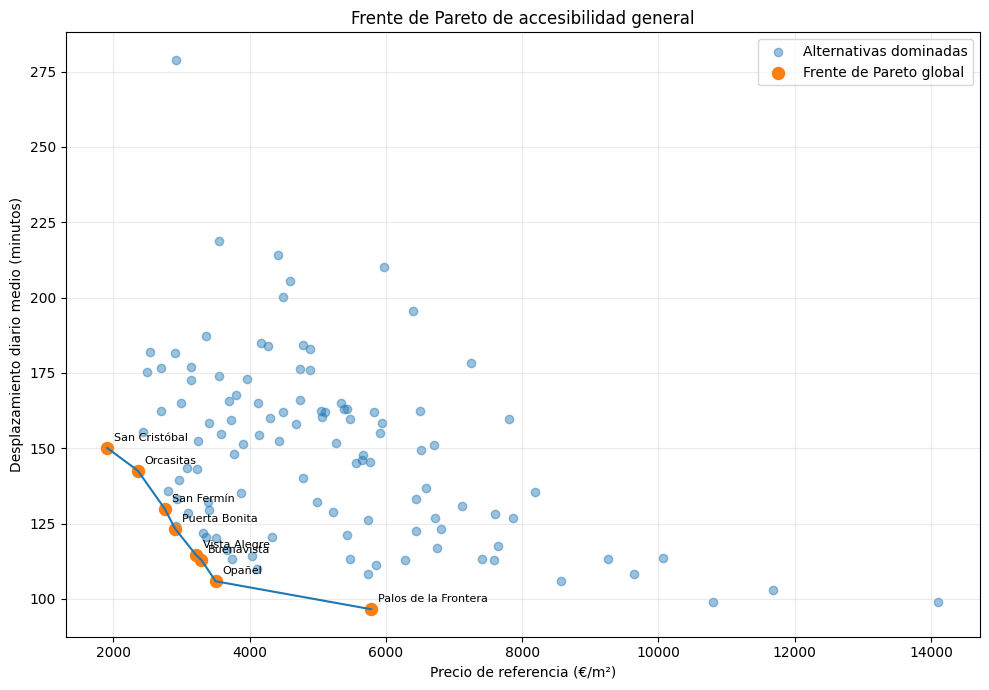

In [773]:
dominated_global = global_zone_data[
    ~global_zone_data["is_pareto_global"]
]

plt.figure(figsize=(10, 7))
plt.scatter(
    dominated_global[
        "price_m2_for_recommender"
    ],
    dominated_global[
        "average_commute_daily_minutes"
    ],
    alpha=0.45,
    label="Alternativas dominadas",
)

plt.scatter(
    global_front[
        "price_m2_for_recommender"
    ],
    global_front[
        "average_commute_daily_minutes"
    ],
    s=75,
    label="Frente de Pareto global",
)

plt.plot(
    global_front[
        "price_m2_for_recommender"
    ],
    global_front[
        "average_commute_daily_minutes"
    ],
    linewidth=1.5,
)

for _, row in (
    global_front
    .sort_values("distance_to_ideal_global")
    .head(12)
    .iterrows()
):
    plt.annotate(
        row["neighborhood_name"],
        (
            row["price_m2_for_recommender"],
            row["average_commute_daily_minutes"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("Precio de referencia (€/m²)")
plt.ylabel("Desplazamiento diario medio (minutos)")
plt.title(
    "Frente de Pareto de accesibilidad general"
)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Guardado de resultados

Se guardan varios archivos para que los siguientes notebooks puedan reutilizar los resultados sin repetir todo el cálculo:

- *pareto_by_destination.csv*: todas las alternativas, indicando si pertenecen o no al frente.
- *pareto_front_by_destination.csv*: únicamente las alternativas Pareto-óptimas.
- *pareto_summary_by_destination.csv*: resumen por destino.
- *pareto_global_accessibility.csv*: análisis complementario con la media de todos los destinos.
- *pareto_profile_examples.csv*: ejemplo de recomendación para tres perfiles de preferencias.
- *pareto_marginal_tradeoffs.csv*: incremento de precio y reducción de tiempo al pasar entre alternativas consecutivas del frente.
- *pareto_weight_sensitivity.csv*: recomendación obtenida para cada destino al variar progresivamente los pesos de precio y tiempo.

In [774]:
pareto_results.to_csv(
    PARETO_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig",
)

pareto_front.to_csv(
    PARETO_FRONT_PATH,
    index=False,
    encoding="utf-8-sig",
)

pareto_summary.to_csv(
    PARETO_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

global_zone_data.to_csv(
    PARETO_GLOBAL_PATH,
    index=False,
    encoding="utf-8-sig",
)

profile_examples.to_csv(
    PARETO_PROFILES_PATH,
    index=False,
    encoding="utf-8-sig",
)

marginal_tradeoffs.to_csv(
    PARETO_TRADEOFF_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_sensitivity.to_csv(
    PARETO_SENSITIVITY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Archivos generados:")

for path in [
    PARETO_RESULTS_PATH,
    PARETO_FRONT_PATH,
    PARETO_SUMMARY_PATH,
    PARETO_GLOBAL_PATH,
    PARETO_PROFILES_PATH,
    PARETO_TRADEOFF_PATH,
    PARETO_SENSITIVITY_PATH,
]:
    print(
        "-",
        path.relative_to(PROJECT_ROOT),
    )

Archivos generados:
- data\results\pareto_by_destination.csv
- data\results\pareto_front_by_destination.csv
- data\results\pareto_summary_by_destination.csv
- data\results\pareto_global_accessibility.csv
- data\results\pareto_profile_examples.csv
- data\results\pareto_marginal_tradeoffs.csv
- data\results\pareto_weight_sensitivity.csv


## 13. Validaciones finales

Como última comprobación se verifica que:

- Todas las alternativas marcadas como Pareto tienen cero dominadores.
- Ninguna alternativa dominada tiene cero dominadores.
- Todos los destinos tienen al menos una alternativa en su frente.
- Los archivos de resultados conservan las claves de barrio y destino.
- Todas las recomendaciones del análisis de sensibilidad pertenecen al frente de Pareto de su destino.
- Para cada destino se evalúa exactamente una recomendación por cada combinación de pesos.
- Los incrementos de precio entre alternativas consecutivas del frente son no negativos.
- El paso hacia alternativas más caras del frente supone una reducción no negativa del tiempo de desplazamiento.

In [775]:
assert (
    pareto_results.loc[
        pareto_results["is_pareto"],
        "dominated_by_count",
    ]
    .eq(0)
    .all()
), (
    "Alguna alternativa Pareto aparece dominada."
)

In [776]:
assert (
    pareto_results.loc[
        ~pareto_results["is_pareto"],
        "dominated_by_count",
    ]
    .gt(0)
    .all()
), (
    "Alguna alternativa no Pareto aparece sin dominadores."
)

In [777]:
pareto_count_by_destination = (
    pareto_results.groupby(
        "destination_id"
    )["is_pareto"]
    .sum()
)

In [778]:
assert (
    pareto_count_by_destination > 0
).all(), (
    "Algún destino no tiene alternativas Pareto."
)

In [779]:
assert pareto_results[
    ["zone_key", "destination_id"]
].notna().all().all()

In [780]:
assert np.isclose(
    weight_sensitivity["price_weight"]
    + weight_sensitivity["time_weight"],
    1.0,
).all(), (
    "Alguna combinación de pesos no suma 1."
)

expected_weight_evaluations = len(
    WEIGHT_GRID
)

assert (
    weight_sensitivity.groupby(
        "destination_id"
    )
    .size()
    .eq(expected_weight_evaluations)
    .all()
), (
    "No se ha evaluado el mismo número de pesos "
    "para todos los destinos."
)

pareto_key_pairs = set(
    map(
        tuple,
        pareto_front[
            [
                "destination_id",
                "zone_key",
            ]
        ].to_numpy(),
    )
)

sensitivity_key_pairs = set(
    map(
        tuple,
        weight_sensitivity[
            [
                "destination_id",
                "zone_key",
            ]
        ].to_numpy(),
    )
)

assert sensitivity_key_pairs.issubset(
    pareto_key_pairs
), (
    "El análisis de sensibilidad ha seleccionado "
    "alguna alternativa que no pertenece al frente de Pareto."
)

valid_tradeoff_rows = (
    marginal_tradeoffs[
        "extra_price_eur_m2_vs_previous"
    ]
    .notna()
)

assert (
    marginal_tradeoffs.loc[
        valid_tradeoff_rows,
        "extra_price_eur_m2_vs_previous",
    ]
    .ge(0)
    .all()
), (
    "El frente no está correctamente ordenado por precio."
)

assert (
    marginal_tradeoffs.loc[
        valid_tradeoff_rows,
        "daily_minutes_saved_vs_previous",
    ]
    .ge(0)
    .all()
), (
    "Algún paso del frente aumenta el precio "
    "sin reducir el tiempo."
)

In [781]:
print(
    "Todas las validaciones del análisis de Pareto se han superado correctamente."
)

Todas las validaciones del análisis de Pareto se han superado correctamente.


## 14. Conclusiones

El análisis de Pareto permite representar de forma explícita el principal problema de decisión del recomendador: encontrar barrios con un precio razonable sin asumir un tiempo de desplazamiento excesivo.

Los resultados confirman que no existe necesariamente una única alternativa que sea mejor en todos los criterios. Los barrios con menor precio suelen requerir desplazamientos más largos, mientras que las zonas con trayectos más rápidos pueden presentar precios considerablemente superiores. El frente de Pareto conserva aquellas alternativas en las que no es posible mejorar uno de los objetivos sin empeorar el otro.

El análisis se ha realizado de forma independiente para cada destino. Esta decisión es necesaria porque la accesibilidad de un barrio depende del lugar concreto al que debe desplazarse el usuario. Por tanto, no sería metodológicamente correcto construir una única clasificación universal de barrios sin conocer antes el destino habitual.

Además de identificar el frente, se ha calculado una referencia equilibrada mediante la distancia normalizada al punto ideal. Esta selección no modifica la pertenencia al frente de Pareto y debe interpretarse únicamente como una ayuda cuando el usuario todavía no ha indicado sus preferencias.

El análisis del coste marginal permite cuantificar cuánto aumenta el precio de referencia al pasar hacia alternativas con menores tiempos de desplazamiento. Por su parte, el análisis de sensibilidad muestra cómo cambia la recomendación cuando varía progresivamente la importancia asignada al precio y al tiempo. De esta forma, las recomendaciones no dependen únicamente de tres combinaciones de pesos escogidas de manera aislada.

Pareto funciona como una primera fase del sistema de recomendación:

1. Descarta las alternativas claramente peores en precio y tiempo.
2. Conserva un conjunto de barrios eficientes para cada destino.
3. Cuantifica el intercambio entre coste y desplazamiento.
4. Permite aplicar posteriormente restricciones personales y métodos como KNN utilizando características inmobiliarias, presupuesto, tiempos máximos, caminata, espera y transbordos.

### Limitaciones

Los precios empleados son valores de referencia por metro cuadrado y no tasaciones de viviendas concretas. El precio orientativo para 80 m² es únicamente una transformación del valor por metro cuadrado y no incluye impuestos, gastos de compraventa, estado de conservación o posibles reformas.

Los tiempos de transporte se han calculado desde una única coordenada representativa de cada barrio. Por ello, no recogen las diferencias que pueden existir entre distintas calles o viviendas dentro de una misma zona.

Asimismo, las rutas se basan en horarios planificados y en una fecha y unas franjas horarias determinadas. No incorporan retrasos reales, incidencias, obras o variaciones extraordinarias del servicio.

El análisis combina información inmobiliaria de referencia de 2025 con los tiempos correspondientes a la fecha de servicio utilizada en OpenTripPlanner. Por tanto, debe interpretarse como una aproximación transversal construida a partir de distintas fuentes y momentos de actualización.

La normalización min–max y los pesos influyen en la alternativa seleccionada como equilibrada o recomendada, pero no modifican qué barrios forman parte del frente de Pareto.

Finalmente, los casos `no_route` y las rutas parciales se han conservado en el dataset completo sin rellenar sus valores mediante medias o estimaciones artificiales. No participan en Pareto porque no permiten realizar una comparación equivalente con las rutas completas.

In [782]:
final_summary = pd.Series(
    {
        "complete_rows_received": len(model_data),
        "rows_used_in_pareto": len(pareto_base),
        "destinations_analyzed": pareto_base[
            "destination_id"
        ].nunique(),
        "neighborhoods_analyzed": pareto_base[
            "zone_key"
        ].nunique(),
        "pareto_rows_by_destination": len(
            pareto_front
        ),
        "global_complete_neighborhoods": len(
            global_zone_data
        ),
        "global_pareto_neighborhoods": len(
            global_front
        ),
        "marginal_tradeoff_rows": len(
            marginal_tradeoffs
        ),
        "weight_combinations_evaluated": len(
            weight_sensitivity
        ),
        "unique_sensitivity_recommendations": (
            weight_sensitivity[
                [
                    "destination_id",
                    "zone_key",
                ]
            ]
            .drop_duplicates()
            .shape[0]
        ),
    }
)


In [783]:
display(
    final_summary.to_frame("value")
)

,value
complete_rows_received,371
rows_used_in_pareto,371
destinations_analyzed,3
neighborhoods_analyzed,128
pareto_rows_by_destination,28
global_complete_neighborhoods,115
global_pareto_neighborhoods,8
marginal_tradeoff_rows,28
weight_combinations_evaluated,63
unique_sensitivity_recommendations,12


In [784]:
print(
    "\nNotebook 08 finalizado correctamente."
)


Notebook 08 finalizado correctamente.
